In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("data.csv")
df_genres = pd.read_csv("data_w_genres.csv")
df_artist = pd.read_csv("data_by_artist.csv")
df_year = pd.read_csv("data_by_year.csv")
df_genre_summary = pd.read_csv("data_by_genres.csv")

In [4]:
df.head()
df.info()
df.describe()

df_artist.head()
df_year.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.205710,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.240720,-19.275282,0.116655,100.884521,0.535549,0.140845,10
2,1,1923,0.957247,0.577341,177942.362162,0.262406,0.371733,0.227462,-14.129211,0.093949,114.010730,0.625492,5.389189,0
3,1,1924,0.940200,0.549894,191046.707627,0.344347,0.581701,0.235219,-14.231343,0.092089,120.689572,0.663725,0.661017,10
4,1,1925,0.962607,0.573863,184986.924460,0.278594,0.418297,0.237668,-14.146414,0.111918,115.521921,0.621929,2.604317,5


In [5]:
df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

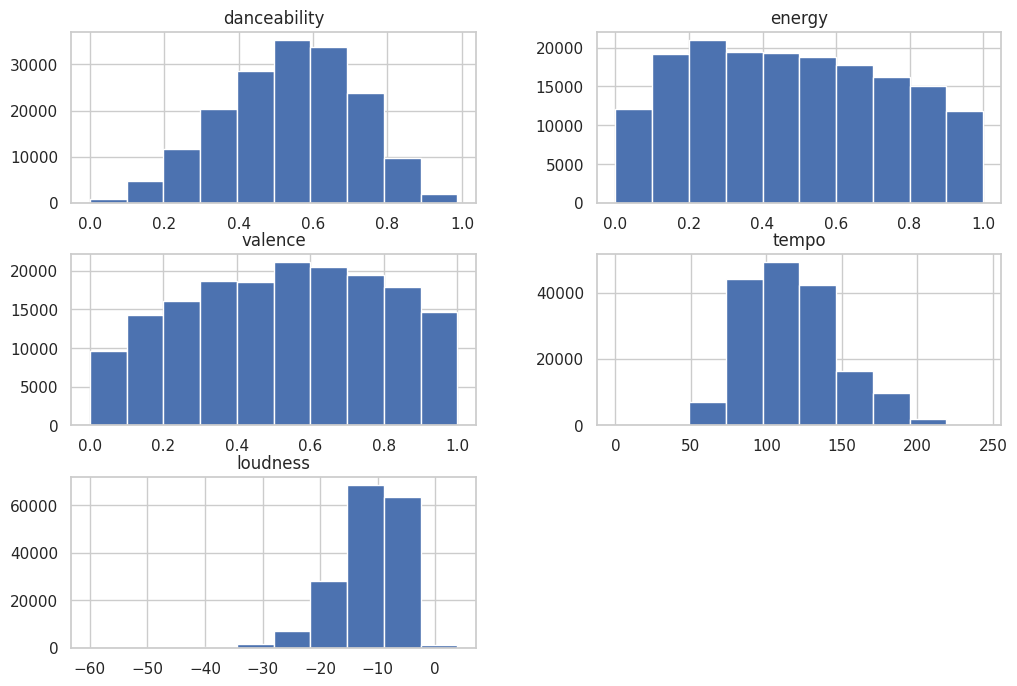

In [7]:
features = ['danceability','energy','valence','tempo','loudness']

df[features].hist(figsize=(12,8))
plt.show()

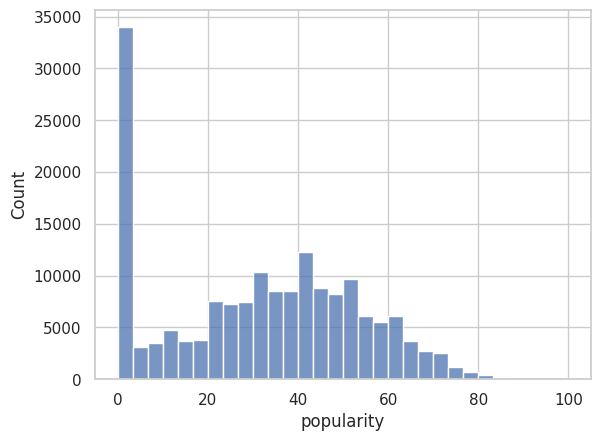

In [8]:
sns.histplot(df['popularity'], bins=30)
plt.show()

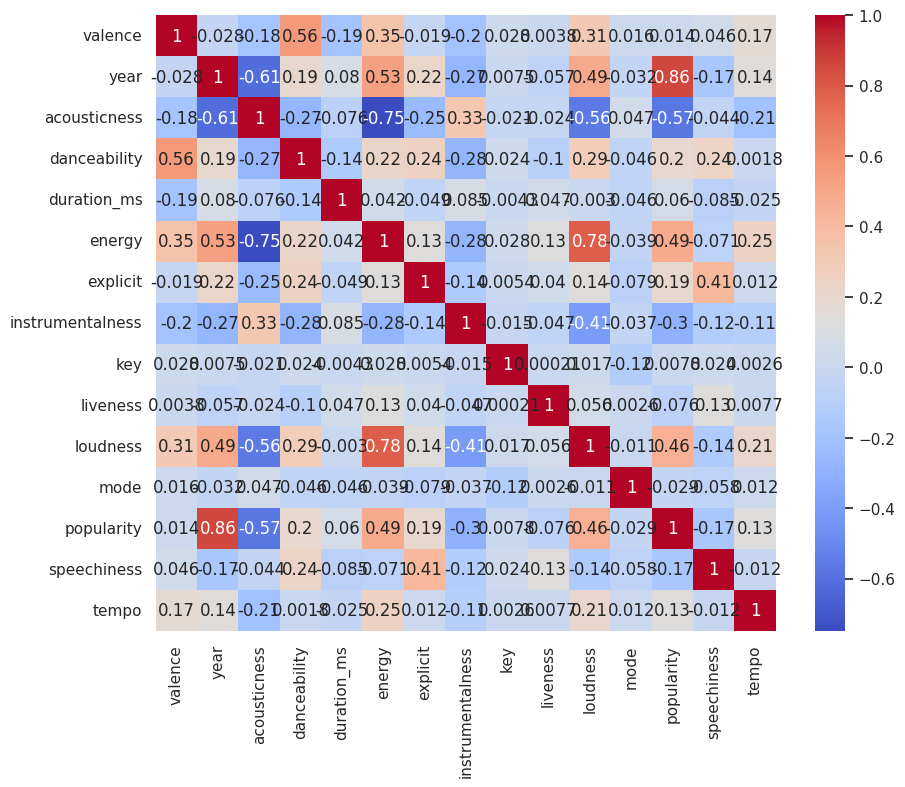

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

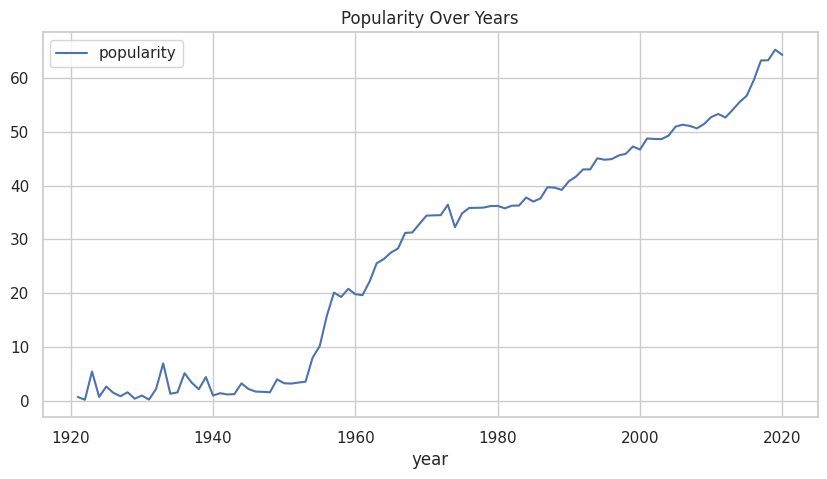

In [10]:
df_year.plot(x='year', y='popularity', figsize=(10,5))
plt.title("Popularity Over Years")
plt.show()

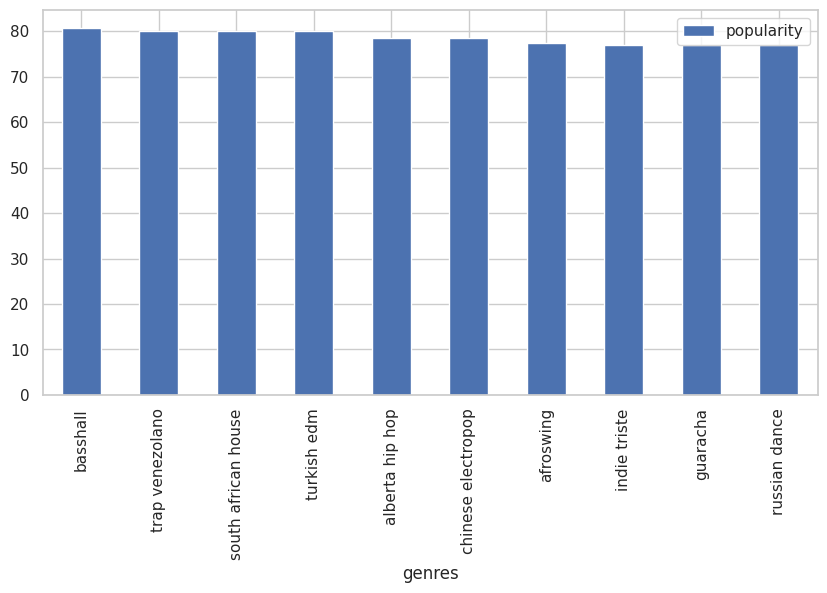

In [11]:
df_genre_summary.sort_values(by='popularity', ascending=False).head(10).plot(
    x='genres', y='popularity', kind='bar', figsize=(10,5)
)
plt.show()

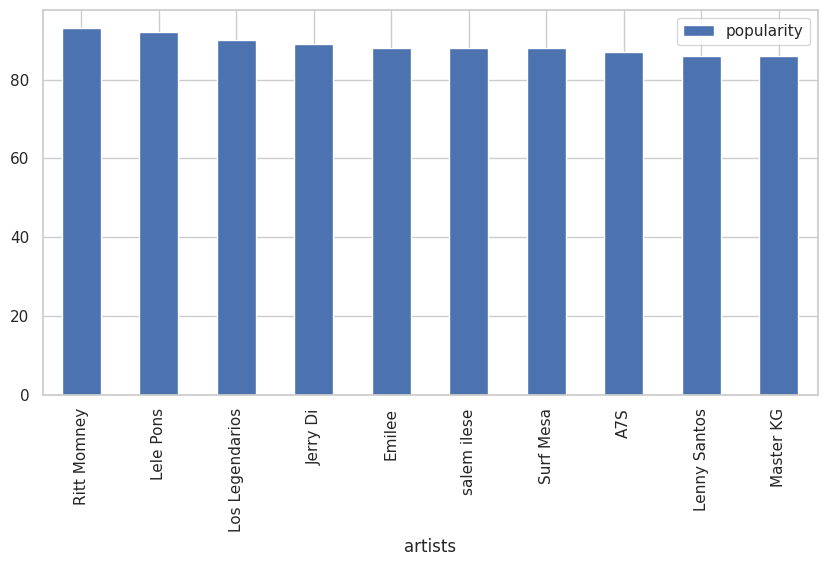

In [12]:
df_artist.sort_values(by='popularity', ascending=False).head(10).plot(
    x='artists', y='popularity', kind='bar', figsize=(10,5)
)
plt.show()

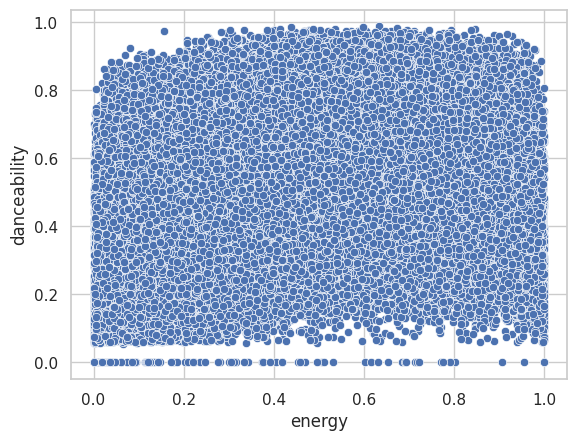

In [13]:
sns.scatterplot(x='energy', y='danceability', data=df)
plt.show()

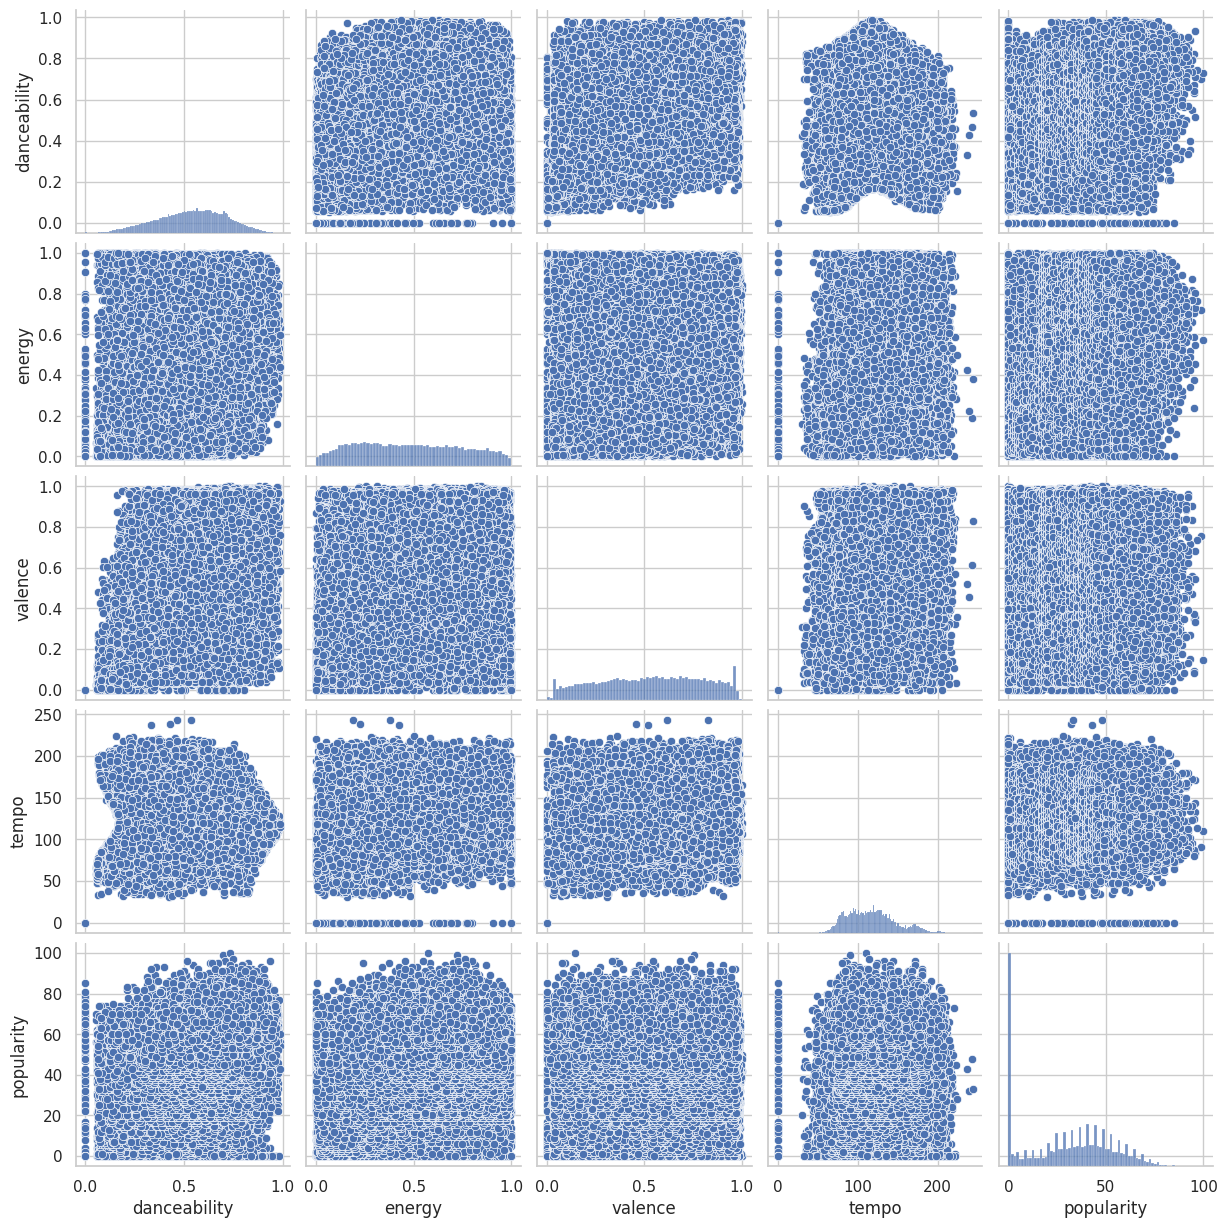

In [14]:
sns.pairplot(df[['danceability','energy','valence','tempo','popularity']])
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X = df[['danceability','energy','valence','tempo','loudness']]
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression R2: 0.324718207921338
MSE: 323.13399815262915


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression R2: 0.324718207921338
MSE: 323.13399815262915


In [19]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred_dt))

Decision Tree R2: -0.1413885907992467


In [20]:
df.to_csv("cleaned_spotify_data.csv", index=False)